# **CMSC 320 Final Project — Checkpoint 2**

**Members:** Pranav Samuel, Aarav Nirmal, Manan Rajput  

## **Objective**  
The goal of this project is to explore which factors (such as budget, genre, popularity, and ratings) most strongly influence a movie’s financial and critical success.

## **Datasets**  
- TMDB 5000 Movie Metadata (Kaggle)  
- Worldwide Box Office Rankings (Kaggle)  

## **Tests We Plan To Run:** 

### **1.** **Production Efficiency (Chi-Square)**  

##### **Type: Chi-Squared Test of Independence**
- We will categorize movies into "High Budget" vs. "Low Budget" (using the median) and "Flop" vs. "Success" (Revenue < Budget vs. Revenue > Budget).
- This test answers the question, "Does spending more money statistically decrease your risk of failing, or are low-budget movies actually safer bets?"
- $H_0$: There is no association between budget size (High vs. Low) and financial outcome (Success vs. Flop). They are independent.
- $H_A$: There is a significant association between budget size and financial outcome. (e.g., High-budget movies are statistically more likely to be successes than low-budget movies).
- The plot we will use is the Stacked Bar Chart


### **2.** **Artistic Effects: Director-Writer Overlap**
    
##### **Type: Comparison of Means (Two-Sample t-test)**
- We will create two groups: Group A (Movies where the Director is also a Writer) and Group B (Movies where they are different people). We then compare their Average Ratings.
- This test answers: "Does a singular idea lead to a statistically significant increase in movie quality, or is it better to have specialists?"
- $H_0$: The mean Average Rating for movies with a Director-Writer overlap is equal to the mean Average Rating for movies with separate specialists ($\mu_1 = \mu_2$).
- $H_A$: The mean Average Rating for movies with a Director-Writer overlap is significantly different from movies with separate specialists ($\mu_1 \neq \mu_2$).
- The plot we will use is the Box Plot with points 

### **3.** **Market Analysis: ANOVA (5 Genres vs. Box Office Revenue)**

##### **Type: Analysis of Variance (Multiple Group Comparison)**
- We take the big three distinct genre buckets (Energy, Suspenseful, Stylized, Emotional, and Lighthearted) and compare their Worldwide Revenue.
- This test answers: "Is there a premier genre that consistently outperforms the others, or is the financial difference between genres just a matter of chance?"
- $H_0$: The mean Worldwide Revenue is the same across all five genre groups ($\mu_{Energy} = \mu_{Suspenseful} = \mu_{Stylized} = \mu_{Emotional} = \mu_{Lightheated}$).
- $H_A$: At least one genre group has a mean Worldwide Revenue that is significantly different from the others.
- The plot we will use is the Bar Chart with Error Bars

Data We Need For Tests:
1. Worldwide Revenue (Adj.) ✔️
2. Budget (Adj.) ✔️
3. Rating Data  ✔️
4. Crew (Writing) ✔️
5. Director ✔️
6. Genre Data  ✔️

Test1: (1, 2) -> Revenue and Budget

Test2: (3, 4, 5) -> Rating, Crew, and Director

Test3: (1, 6) -> Revenue and Genre Data

Columns for Combined CSV: 
- Revenue(Adj) (Integer)

- Budget(Adj) (Integer)

- Rating Data (Double)

- Crew (String List)

- Director (String)

- Genre Data (String)

Columns to Add for Analysis:
- Profit Margin
- Director in Writing Crew? (Boolean)

## **Imports**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob as glob
import json
from scipy.stats import chi2_contingency
import scipy.stats as stats
import seaborn as sns
# other imports

Matplotlib is building the font cache; this may take a moment.


## **Data Loading**

In this section, we import the datasets and inspect their structure. The next steps involve inspecting the structure of these datasets (columns, data types, missing values) to make sure they are erady for merging and analysis. The first two datasets are our list of 5000 movies with different information about the movies. The Consumer Price Index dataset is being loaded to adjust for inflation and thus, ensuring fair comparisons across different years.

`tmdb_movies` contains movie metadata (genres, budgets, revenues, ratings, etc.)  
`tmdb_credits` contains information about the cast and crrew (directors, writers, actors, etc.)  
`cpi` contains monthly Consumer Price Index values from 1960-present

These datasets will later be merged to create a more comprehensive dataset for analysis.

In [ ]:
tmdb_movies = pd.read_csv("data/tmdb/tmdb_5000_movies.csv")
tmdb_credits = pd.read_csv("data/tmdb/tmdb_5000_credits.csv")

cpi = pd.read_csv("data/cpi/CORESTICKM159SFRBATL.csv")

## **Data Preprocessing**

In this section, we are going to clean and setup the data for analysis.

First, we are going to look into our revenues and adjust them according to inflation with out CPI dataset. We rename the columns in the CPI dataset for clarity. Then, we convert the date column to a datetime format, and the year is extracted to group CPI values by year. We finally calculate the average CPI each year to create a `yearly_cpi` dataset, which will be used to adjust revenue and budget values for inflation.

In [ ]:
# setting up cpi for grouping by year
cpi.columns = ["date", "cpi"]
cpi['date'] = pd.to_datetime(cpi['date'])
cpi['year'] = cpi['date'].dt.year
cpi['cpi'] = pd.to_numeric(cpi['cpi'], errors='coerce')

yearly_cpi = cpi.groupby('year')['cpi'].mean().reset_index()
display(yearly_cpi)

,year,cpi
0,1968,4.599479
1,1969,6.360164
2,1970,7.040731
3,1971,5.100820
4,1972,3.554771
5,1973,3.603410
6,1974,8.805786
7,1975,9.928061
8,1976,7.025373
9,1977,6.695581


Using `glob`, we load multiple box office revenue files and iterate through them.  

For each file:
- Extract the year from the filename
- Merge the dataset with our `yearly_cpi` dataset to get the CPI for the corresponding year
- Clean the `worldwide` revenue and convert it to numeric
- Apply the inflation-adjustment formula `revenue_adjusted = worldwide * (latest_cpi / cpi)`

We then combined all the datasets to a single `combined_movies` DataFrame and remove any unnecessary columns.

In [ ]:
# list all our files
movie_files = glob.glob("data/box_office/ranking_summary_*.csv")

adjusted_movies_list = []
latest_cpi = yearly_cpi['cpi'].iloc[-1]

# apply cpi to each file
for file in movie_files:
    df = pd.read_csv(file)
    
    # get the year from title
    year_from_file = int(file.split('_')[3].split('.')[0])
    df['year'] = year_from_file

    df = df.merge(yearly_cpi, on='year', how='left')
    
    # adjust for inflation
    df['worldwide'] = df['worldwide'].replace('[$,]', '', regex=True)
    df['worldwide'] = pd.to_numeric(df['worldwide'], errors='coerce')
    df['revenue_adjusted'] = df['worldwide'] * (latest_cpi / df['cpi'])
    
    # add each df to combine
    adjusted_movies_list.append(df)

combined_movies = pd.concat(adjusted_movies_list, ignore_index=True)
combined_movies = combined_movies.drop(columns=['rank','cpi', 'worldwide', 'domestic', 'domestic_pct', 'foreign', 'foreign_pct', 'year'])
combined_movies.head()

,title,revenue_adjusted
0,Ne Zha 2,NaN
1,Zootopia 2,NaN
2,Avatar: Fire and Ash,NaN
3,Lilo & Stitch,NaN
4,A Minecraft Movie,NaN


This step combines the metadata (`tmdb_movies`) and cast/crew information (`tmdb_credits`) into a single dataset (`tmdb_full`) based on `title`. By dropping unnecessary columns, we streamline the dataset, making it easier to work with making sure only relevant information is retained. This prepares the data for further preprocessing and merging.

In [ ]:
# merging our two tmdb datasets
tmdb_movies['title'] = tmdb_movies['title'].astype(str)
tmdb_credits['title'] = tmdb_credits['title'].astype(str)

tmdb_full = pd.merge(tmdb_movies, tmdb_credits, on='title', how='inner')

# dropping unnecessary columns
tmdb_full = tmdb_full.drop(columns=['id', 'tagline', 'status','overview', 'keywords', 'homepage', 'original_title', 'popularity', 'production_companies', 'production_countries', 'revenue', 'cast', 'spoken_languages'])
tmdb_full.head()

,budget,genres,original_language,release_date,runtime,title,vote_average,vote_count,movie_id,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2009-12-10,162.0,Avatar,7.2,11800,19995,"[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",en,2007-05-19,169.0,Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2015-10-26,148.0,Spectre,6.3,4466,206647,"[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",en,2012-07-16,165.0,The Dark Knight Rises,7.6,9106,49026,"[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2012-03-07,132.0,John Carter,6.1,2124,49529,"[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


Our next objective is to adjust the budget values in our `tmdb_full` dataset to account for inflation. We follow the same process we did for the revenues previously. We alos drop the `cpi` and the original `budget` columns because they are irrelevant now. After adjusting the budget, we rearrange the columns to make it more organized.

In [ ]:
# adjust for budget with cpi (same process as before)
tmdb_full['release_date'] = pd.to_datetime(tmdb_full['release_date'])
tmdb_full['year'] = tmdb_full['release_date'].dt.year

tmdb_full = tmdb_full.merge(yearly_cpi, on='year', how='left')
tmdb_full['budget'] = pd.to_numeric(tmdb_full['budget'], errors='coerce')

tmdb_full['budget_adjusted'] = tmdb_full['budget'] * (latest_cpi / tmdb_full['cpi'])

# dropping cpi
tmdb_full = tmdb_full.drop(columns=['cpi', 'budget'])

# rearranging rows
tmdb_full = tmdb_full[['movie_id', 'title', 'genres','original_language', 'year', 'release_date', 'budget_adjusted','crew', 'vote_average', "vote_count"]]
tmdb_full

,movie_id,title,genres,original_language,year,release_date,budget_adjusted,crew,vote_average,vote_count
0,19995,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2009.0,2009-12-10,5.211635e+08,"[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.2,11800
1,285,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",en,2007.0,2007-05-19,4.727022e+08,"[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.9,4500
2,206647,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2015.0,2015-10-26,4.929587e+08,"[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.3,4466
3,49026,The Dark Knight Rises,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",en,2012.0,2012-07-16,5.002568e+08,"[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.6,9106
4,49529,John Carter,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2012.0,2012-03-07,5.202671e+08,"[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",6.1,2124
...,...,...,...,...,...,...,...,...,...,...
4804,9367,El Mariachi,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",es,1992.0,1992-09-04,2.533451e+05,"[{""credit_id"": ""52fe44eec3a36847f80b280b"", ""de...",6.6,238
4805,72766,Newlyweds,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",en,2011.0,2011-12-26,2.675839e+04,"[{""credit_id"": ""52fe487dc3a368484e0fb013"", ""de...",5.9,5
4806,231617,"Signed, Sealed, Delivered","[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",en,2013.0,2013-10-13,0.000000e+00,"[{""credit_id"": ""52fe4df3c3a36847f8275ecf"", ""de...",7.0,6
4807,126186,Shanghai Calling,[],en,2012.0,2012-05-03,0.000000e+00,"[{""credit_id"": ""52fe4ad9c3a368484e16a36b"", ""de...",5.7,7


We are merging the two datasets we have (`tmdb_full` and `combined_movies`). This will give us a holistic form of analysis of the movies. There are however certain issues with merging, for example movies which may not match (only in one of the databases) as well as having overlapping data. We overcome these issues by only choosing to take movies which are properly represented in both databases as well as taking priority of revenue information in the `combined_movies` database. 

In [ ]:
tmdb_full['title'] = tmdb_full['title'].astype(str).str.strip()
combined_movies['title'] = combined_movies['title'].astype(str).str.strip()

merged_movies = pd.merge(
    tmdb_full,
    combined_movies,
    on='title',
    how='inner'
)

merged_movies

,movie_id,title,genres,original_language,year,release_date,budget_adjusted,crew,vote_average,vote_count,revenue_adjusted
0,19995,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2009.0,2009-12-10,5.211635e+08,"[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.2,11800,6.033133e+09
1,285,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",en,2007.0,2007-05-19,4.727022e+08,"[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.9,4500,1.514217e+09
2,206647,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2015.0,2015-10-26,4.929587e+08,"[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.3,4466,1.771985e+09
3,49026,The Dark Knight Rises,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",en,2012.0,2012-07-16,5.002568e+08,"[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.6,9106,2.170993e+09
4,49529,John Carter,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2012.0,2012-03-07,5.202671e+08,"[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",6.1,2124,5.685701e+08
...,...,...,...,...,...,...,...,...,...,...,...
3201,38780,Rampage,"[{""id"": 28, ""name"": ""Action""}, {""id"": 18, ""nam...",en,2009.0,2009-08-14,0.000000e+00,"[{""credit_id"": ""52fe46df9251416c91062979"", ""de...",6.0,131,7.690903e+08
3202,38780,Rampage,"[{""id"": 28, ""name"": ""Action""}, {""id"": 18, ""nam...",en,2009.0,2009-08-14,0.000000e+00,"[{""credit_id"": ""52fe46df9251416c91062979"", ""de...",6.0,131,9.170724e+05
3203,14022,Slacker,"[{""id"": 35, ""name"": ""Comedy""}]",en,1990.0,1990-07-27,0.000000e+00,"[{""credit_id"": ""52fe45c49251416c75061c17"", ""de...",6.4,77,1.082041e+06
3204,13898,The Circle,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10769, ""n...",fa,2000.0,2000-09-08,0.000000e+00,"[{""credit_id"": ""52fe45b09251416c7505f189"", ""de...",6.6,17,7.860143e+07


For our ANOVA test, we are testing how different genre categories contribute to box office success. In this step, we grouped genres based on more generic categories that we thought were most important. For example, we mapped Action, Adventure, War, and Western to a new genre called Energy (higher-energy films). This will make it easier for the ANOVA hypothesis testing to find differences in box office revenues of the different genres. The different genres being the 5 new generic genres we have developed.

In [ ]:
merged_movies['genres'] = merged_movies['genres'].apply(
    lambda x: [g['name'] for g in json.loads(x)] if isinstance(x, str) else x
)

genre_map = {
    'Action': 'Energy', 'Adventure': 'Energy', 'War': 'Energy', 'Western': 'Energy',
    'Crime': 'Suspense', 'Mystery': 'Suspense', 'Thriller': 'Suspense', 'Horror': 'Suspense',
    'Science Fiction': 'Stylized', 'Fantasy': 'Stylized', 'Animation': 'Stylized',
    'Drama': 'Emotion and Experience', 'Romance': 'Emotion and Experience', 'History': 'Emotion and Experience', 'Documentary': 'Emotion and Experience',
    'Comedy': 'Lighthearted', 'Family': 'Lighthearted', 'Music': 'Lighthearted', 'TV Movie': 'Lighthearted'
}

merged_movies['genres'] = merged_movies['genres'].apply(
    lambda x: list(set(genre_map[g] for g in x if g in genre_map)) if isinstance(x, list) else x
)

merged_movies

,movie_id,title,genres,original_language,year,release_date,budget_adjusted,crew,vote_average,vote_count,revenue_adjusted
0,19995,Avatar,"[Stylized, Energy]",en,2009.0,2009-12-10,5.211635e+08,"[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.2,11800,6.033133e+09
1,285,Pirates of the Caribbean: At World's End,"[Stylized, Energy]",en,2007.0,2007-05-19,4.727022e+08,"[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.9,4500,1.514217e+09
2,206647,Spectre,"[Suspense, Energy]",en,2015.0,2015-10-26,4.929587e+08,"[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.3,4466,1.771985e+09
3,49026,The Dark Knight Rises,"[Suspense, Emotion and Experience, Energy]",en,2012.0,2012-07-16,5.002568e+08,"[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.6,9106,2.170993e+09
4,49529,John Carter,"[Stylized, Energy]",en,2012.0,2012-03-07,5.202671e+08,"[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",6.1,2124,5.685701e+08
...,...,...,...,...,...,...,...,...,...,...,...
3201,38780,Rampage,"[Suspense, Emotion and Experience, Energy]",en,2009.0,2009-08-14,0.000000e+00,"[{""credit_id"": ""52fe46df9251416c91062979"", ""de...",6.0,131,7.690903e+08
3202,38780,Rampage,"[Suspense, Emotion and Experience, Energy]",en,2009.0,2009-08-14,0.000000e+00,"[{""credit_id"": ""52fe46df9251416c91062979"", ""de...",6.0,131,9.170724e+05
3203,14022,Slacker,[Lighthearted],en,1990.0,1990-07-27,0.000000e+00,"[{""credit_id"": ""52fe45c49251416c75061c17"", ""de...",6.4,77,1.082041e+06
3204,13898,The Circle,[Emotion and Experience],fa,2000.0,2000-09-08,0.000000e+00,"[{""credit_id"": ""52fe45b09251416c7505f189"", ""de...",6.6,17,7.860143e+07


## **Hypothesis Testing**

### ***TEST 1: Production Efficiency (Chi-Square)***

we gotta explain more here

outcome          Flop  Success
budget_category               
High              361     1231
Low               211     1379
Chi2: 47.09100894036773
p-value: 6.776583830581104e-12


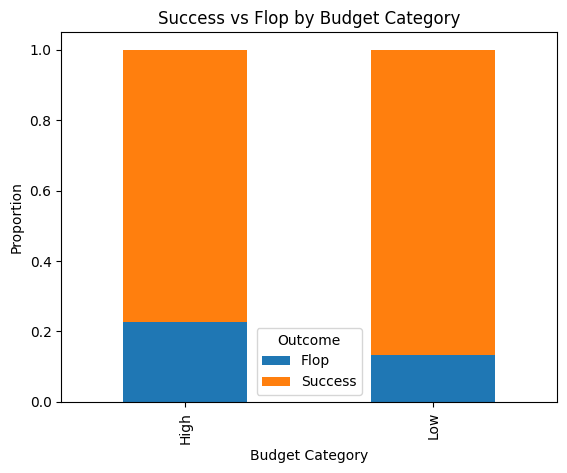

In [ ]:
df = merged_movies.dropna(subset=['budget_adjusted', 'revenue_adjusted'])

# high is the upper 50% and low is the lower 50%
median_budget = df['budget_adjusted'].median()

df['budget_category'] = df['budget_adjusted'].apply(
    lambda x: 'High' if x >= median_budget else 'Low'
)

# success if revenue > budget
df['outcome'] = df.apply(
    lambda row: 'Success' if row['revenue_adjusted'] > row['budget_adjusted'] else 'Flop',
    axis=1
)

# create contingency table
contingency_table = pd.crosstab(df['budget_category'], df['outcome'])
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi2:", chi2)
print("p-value:", p)

# convert to proportions
prop_table = contingency_table.div(contingency_table.sum(axis=1), axis=0)

# plot to stacked bar chart
prop_table.plot(kind='bar', stacked=True)

plt.title("Success vs Flop by Budget Category")
plt.ylabel("Proportion")
plt.xlabel("Budget Category")
plt.legend(title="Outcome")
plt.show()

A chi-square test of independence was conducted to examine the relationship between budget size (high vs. low) and financial outcome (success vs. flop). The results were statistically significant (χ² = 47.09, p < 0.001), indicating that budget category and movie outcome are not independent.

Interestingly, low-budget films exhibited a higher success rate (approximately 86.7%) compared to high-budget films (approximately 77.3%). This suggests that higher spending does not necessarily reduce the risk of failure. In fact, lower-budget films may be safer investments, potentially due to lower financial thresholds required for profitability.

### ***TEST 3: Market Analaysis: ANOVA - 5 Genres vs. Box Office Revenue*** 

we gotta explain some more here

Genre Category: Emotion and Experience    | Number of Movies: 1624
Genre Category: Lighthearted              | Number of Movies: 1399
Genre Category: Suspense                  | Number of Movies: 1295
Genre Category: Energy                    | Number of Movies: 1235
Genre Category: Stylized                  | Number of Movies: 831
ANOVA F-Statistic: 72.9914
ANOVA P-Value: 1.4558e-60


/var/folders/2l/z7qq4pz90fbd8f8dn8kdjzvr0000gn/T/ipykernel_97456/2296717562.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=analysis_df, x='genres', y='revenue_adjusted', capsize=0.1, palette='muted')


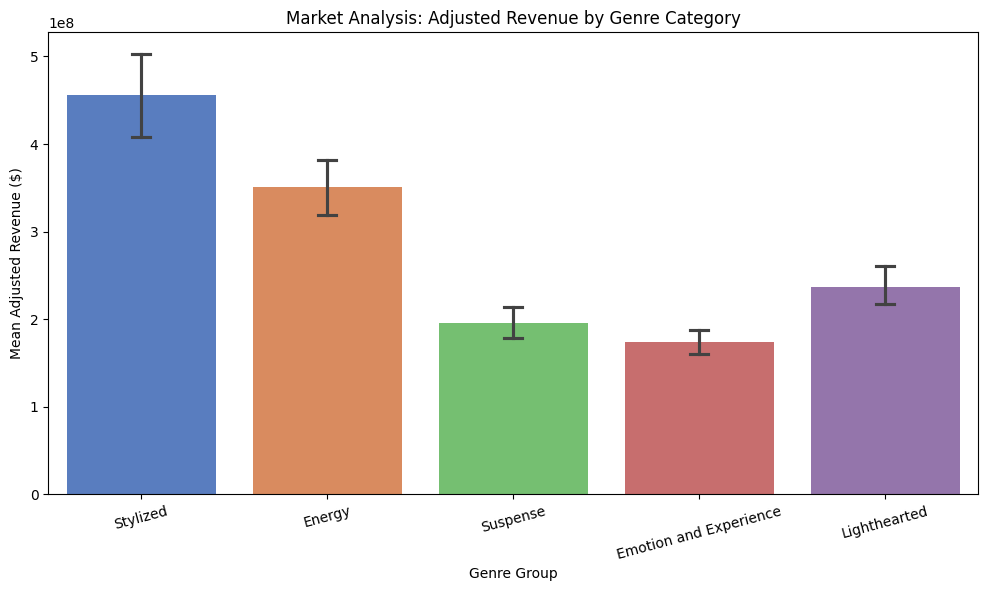

In [ ]:
exploded_movies = merged_movies.explode('genres')

group_sizes = exploded_movies['genres'].value_counts()

for genre, count in group_sizes.items():
    print(f"Genre Category: {genre:<25} | Number of Movies: {count}")

analysis_df = exploded_movies.dropna(subset=['genres', 'revenue_adjusted'])

genre_labels = analysis_df['genres'].unique()
groups = [analysis_df[analysis_df['genres'] == g]['revenue_adjusted'] for g in genre_labels]

f_stat, p_value = stats.f_oneway(*groups)

print(f"ANOVA F-Statistic: {f_stat:.4f}")
print(f"ANOVA P-Value: {p_value:.4e}")

plt.figure(figsize=(12, 6))
sns.barplot(data=analysis_df, x='genres', y='revenue_adjusted', capsize=0.1, palette='muted')
plt.title('Market Analysis: Adjusted Revenue by Genre Category')
plt.ylabel('Mean Adjusted Revenue ($)')
plt.xlabel('Genre Group')
plt.xticks(rotation=15)
plt.show()